
# Линейная регрессия. Практическая работа

# Задача

Пусть у нас имеется некоторый набор данных `sales.csv` о продажах квартир.

- цена продажи (SalePrice, зависимая переменная),
- наземная жилая зона (GrLivArea),
- общее качество (Overall Quality),
- территория гаража (GarageArea),
- условия сделки (SaleCondition).

Реализуйте построение модели линейной регрессии на этих данных. Проверьте качество модели на обучающей и тестовой выборках с помощью MAE, MSE. Определите, что вы не переобучились.

In [ ]:
#https://drive.google.com/file/d/1exPVKQBFI4_TFg_-BAYHtTIn4PFaY6xQ/view?usp=drive_link


!gdown https://drive.google.com/uc?id=1exPVKQBFI4_TFg_-BAYHtTIn4PFaY6xQ

Downloading...
From: https://drive.google.com/uc?id=1exPVKQBFI4_TFg_-BAYHtTIn4PFaY6xQ
To: /content/sales.csv
100% 203k/203k [00:00<00:00, 81.0MB/s]


In [1]:
# подключить необходимые библиотеки
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split # для разбиения
from sklearn.linear_model import LinearRegression # для построения линейной регрессии

from sklearn.metrics import mean_squared_error # для метрики MSE
from sklearn.metrics import mean_absolute_error # для метрики MАE

In [1]:
import sys; print(sys.executable)
1+1

/Users/apple/Documents/GitHub/my_lessons/.venv/bin/python


2

In [6]:
# считать данные
df = pd.read_csv('sales_m.csv')
df.head()

,SalePrice,GrLivArea,GarageArea,OverallQual,Street,SaleCondition
0,208500,1710,548,7,Pave,Normal
1,181500,1262,460,6,Pave,Normal
2,223500,1786,608,7,Pave,Normal
3,140000,1717,642,7,Pave,Abnorml
4,250000,2198,836,8,Pave,Normal


In [ ]:
# проведите анализ данных, посмотрите на индивидуальные графики
# зависимости целевой функции и отдельной переменной
# создайте дополнительные переменные
# для работы с категориальными данными можно воспользоваться pd.get_dummies
# сделайте предварительные выводы

# Ваш код здесь

In [7]:
# проверяем размер и  пустоты
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   SalePrice      1460 non-null   int64 
 1   GrLivArea      1460 non-null   int64 
 2   GarageArea     1460 non-null   int64 
 3   OverallQual    1460 non-null   int64 
 4   Street         1460 non-null   object
 5   SaleCondition  1460 non-null   object
dtypes: int64(4), object(2)
memory usage: 68.6+ KB


в Датасете нет пропусков,  2 признака категориальные

In [8]:
# проверяем дубликаты
df[df.duplicated()]

,SalePrice,GrLivArea,GarageArea,OverallQual,Street,SaleCondition
831,151000,1200,480,7,Pave,Normal


In [9]:
# удаление дублирующих строк
df = df.drop_duplicates()


In [50]:
# функция нахождение подозрительных string в среди цифр
def convert_to_numeric(df):
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except ValueError as e:
            print(f"Ошибка при преобразовании столбца '{col}': {e}")
    return df

# Пример использования:
df = convert_to_numeric(df)

Ошибка при преобразовании столбца 'Street': Unable to parse string "Pave" at position 0
Ошибка при преобразовании столбца 'SaleCondition': Unable to parse string "Normal" at position 0


нашел только стобцы категориальные

смотрим какие там категории

In [35]:
cat_st = df['Street'].unique()
cat_st

array(['Pave', 'Grvl'], dtype=object)

In [36]:
cat_sc= df['SaleCondition'].unique()
cat_sc

array(['Normal', 'Abnorml', 'Partial', 'AdjLand', 'Alloca', 'Family'],
      dtype=object)

In [38]:
columns_list = list(df.columns)
columns_list

['SalePrice',
 'GrLivArea',
 'GarageArea',
 'OverallQual',
 'Street',
 'SaleCondition']

In [54]:
# Получаем список названий числовых колонок
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
numerical_columns

['SalePrice', 'GrLivArea', 'GarageArea', 'OverallQual']

In [55]:
# получаем табличку
numerical_df = df.select_dtypes(include=np.number)
numerical_df

,SalePrice,GrLivArea,GarageArea,OverallQual
0,208500,1710,548,7
1,181500,1262,460,6
2,223500,1786,608,7
3,140000,1717,642,7
4,250000,2198,836,8
...,...,...,...,...
1455,175000,1647,460,6
1456,210000,2073,500,6
1457,266500,2340,252,7
1458,142125,1078,240,5


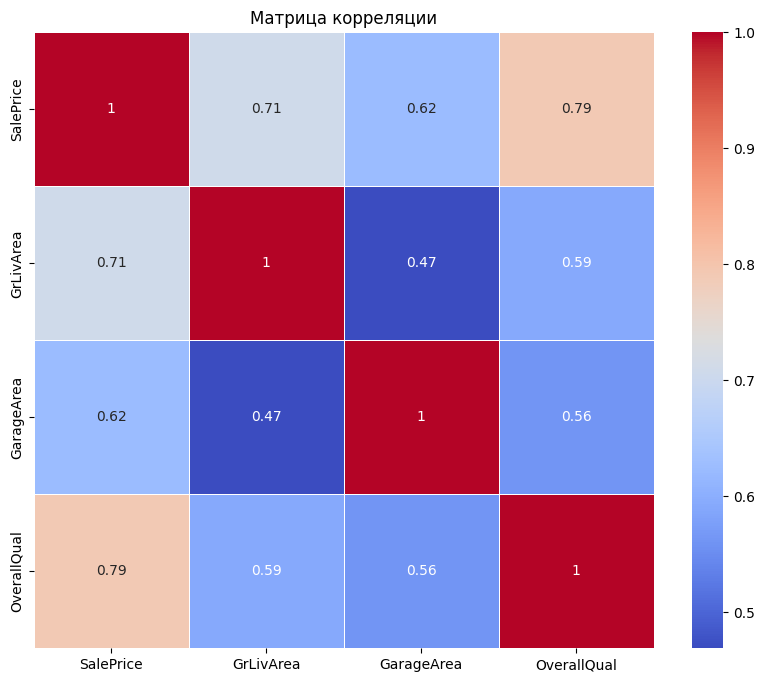

In [56]:
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=.5)
plt.title("Матрица корреляции")
plt.show()

Смотрим какие связи  имеют с ценой

Проведем анализ именно этих данных

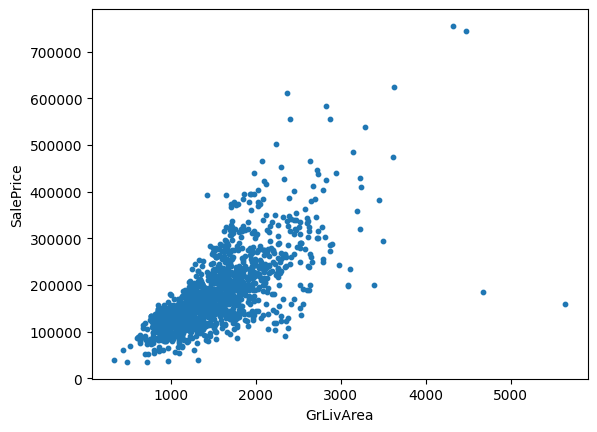

In [58]:
# выведем еще один график  покзаывющий зависимость SalePrice и GrLivArea
plt.scatter(df['GrLivArea'], df['SalePrice'], s=10)
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

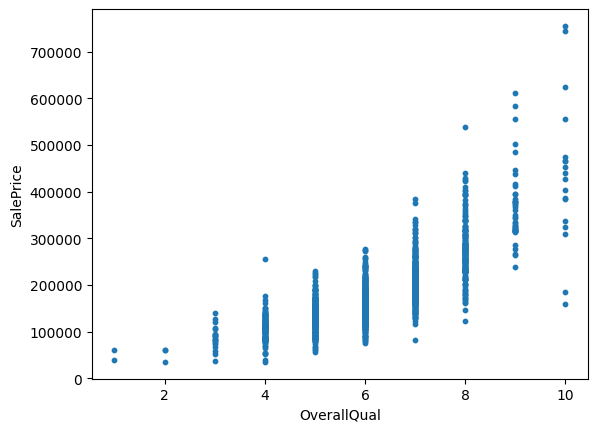

In [59]:
# выведем еще один график  покзаывющий зависимость SalePrice и GrLivArea
plt.scatter(df['OverallQual'], df['SalePrice'], s=10)
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.show()

выдим что есть выбросы  но если мы их сейчас удалим распределение данных потеряет линейность поэтому в учебных целях оставляем выбросы

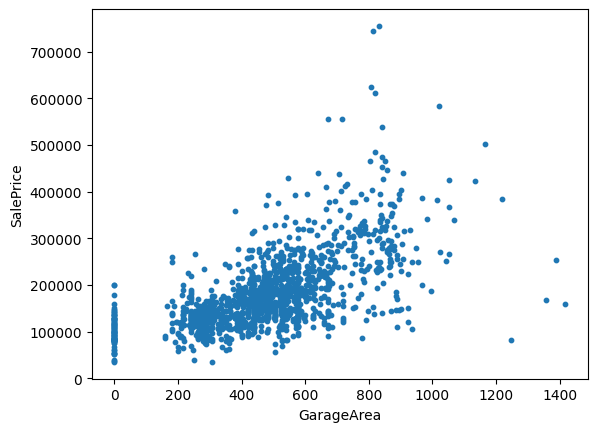

In [61]:
# выведем еще один график  покзаывющий зависимость SalePrice и GrLivArea
plt.scatter(df['GarageArea'], df['SalePrice'], s=10)
plt.xlabel('GarageArea')
plt.ylabel('SalePrice')
plt.show()

In [14]:
# проверим какие наиболее часто встречаются по категориям
stats_1 = df.groupby('SaleCondition').count()
stats_1

,SalePrice,GrLivArea,GarageArea,OverallQual,Street
SaleCondition,,,,,
Abnorml,101,101,101,101,101
AdjLand,4,4,4,4,4
Alloca,12,12,12,12,12
Family,20,20,20,20,20
Normal,1197,1197,1197,1197,1197
Partial,125,125,125,125,125


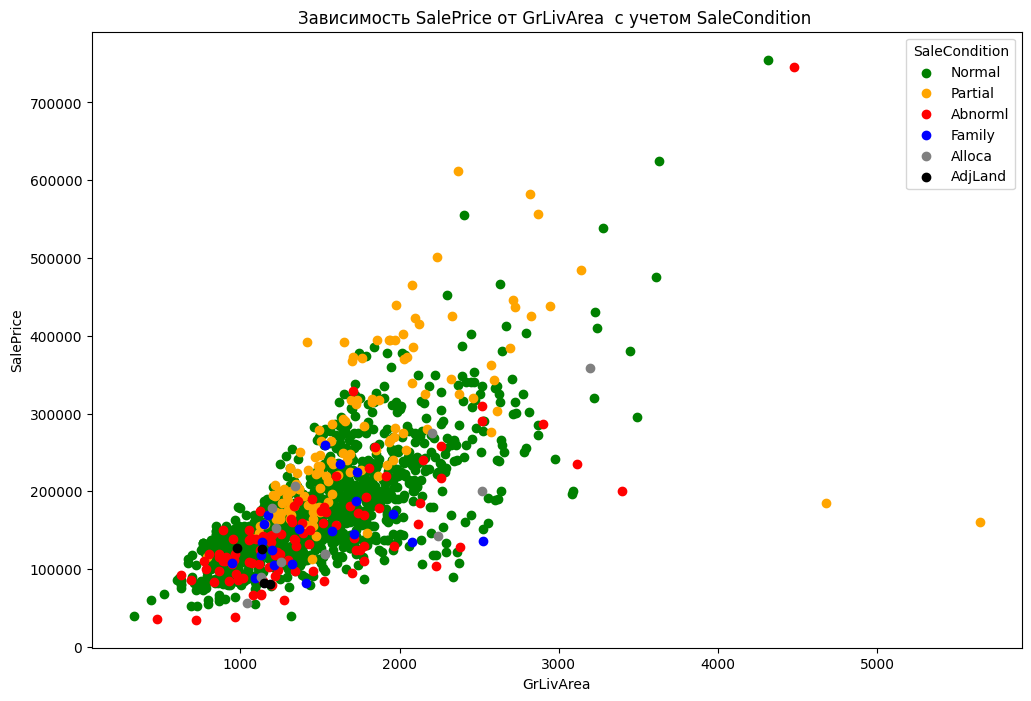

In [62]:
# тот же график с учетом категорий
colors = {'Normal': 'green', 'Partial': 'orange',
          'Abnorml': 'red','Family': 'blue', 'Alloca' : 'grey',
         'AdjLand': 'black'}
fig, ax = plt.subplots(figsize=(12, 8))
for SaleCondition in colors:
    color = colors[SaleCondition]
    data = df[df['SaleCondition'] == SaleCondition]
    ax.scatter(data['GrLivArea'], data['SalePrice'], c=color, label=SaleCondition)

ax.legend(loc='upper right', title="SaleCondition")
plt.title("Зависимость SalePrice от GrLivArea  с учетом SaleCondition ")
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()


Видим большую разбросанность  не подходящую к линейной регрессии  ошибка MSE и MAE будут огромные
 Попробуем выделить одну группу а именно Normal и сделать линейную регрессию для нее

In [63]:
df_sort=df[(df['SaleCondition'] =='Normal')  ]

df_sort

,SalePrice,GrLivArea,GarageArea,OverallQual,Street,SaleCondition
0,208500,1710,548,7,Pave,Normal
1,181500,1262,460,6,Pave,Normal
2,223500,1786,608,7,Pave,Normal
4,250000,2198,836,8,Pave,Normal
5,143000,1362,480,5,Pave,Normal
...,...,...,...,...,...,...
1455,175000,1647,460,6,Pave,Normal
1456,210000,2073,500,6,Pave,Normal
1457,266500,2340,252,7,Pave,Normal
1458,142125,1078,240,5,Pave,Normal


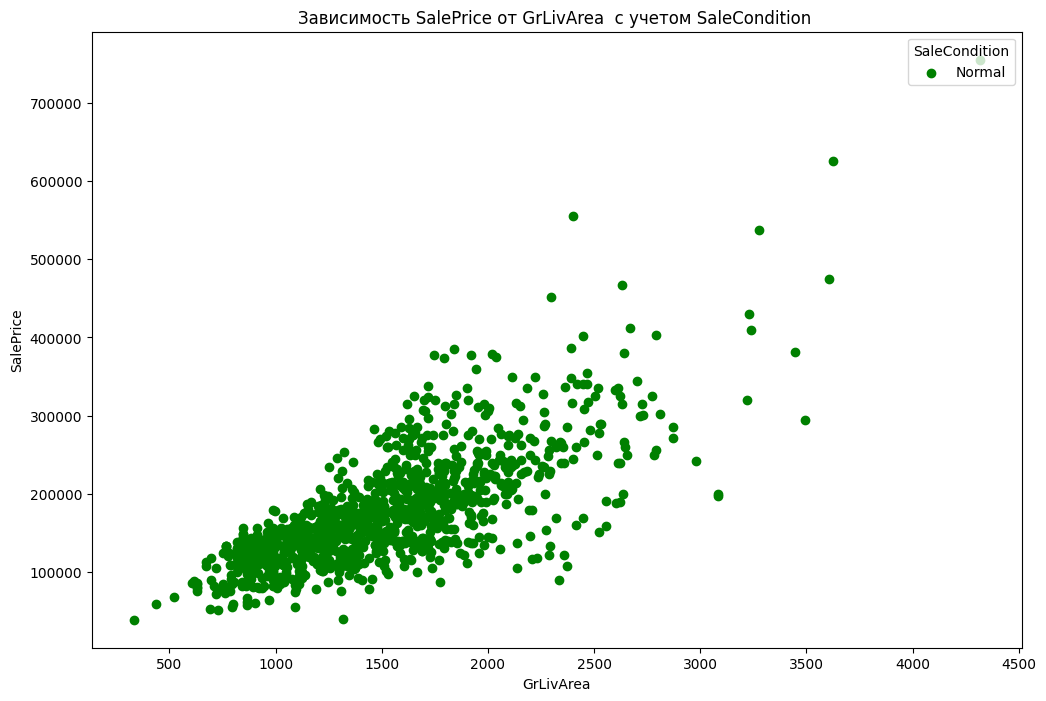

In [64]:
# тот же график с учетом категории Nopmal
colors = {'Normal': 'green'}
fig, ax = plt.subplots(figsize=(12, 8))
for SaleCondition in colors:
    color = colors[SaleCondition]
    data = df_sort[df_sort['SaleCondition'] == SaleCondition]
    ax.scatter(data['GrLivArea'], data['SalePrice'], c=color, label=SaleCondition)

ax.legend(loc='upper right', title="SaleCondition")
plt.title("Зависимость SalePrice от GrLivArea  с учетом SaleCondition ")
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

In [138]:
# получаем новый датасет где категориальные признаки преобразованы
df_new=pd.get_dummies(df_sort)
df_new

,SalePrice,GrLivArea,GarageArea,OverallQual,Street_Grvl,Street_Pave,SaleCondition_Normal
0,208500,1710,548,7,False,True,True
1,181500,1262,460,6,False,True,True
2,223500,1786,608,7,False,True,True
4,250000,2198,836,8,False,True,True
5,143000,1362,480,5,False,True,True
...,...,...,...,...,...,...,...
1455,175000,1647,460,6,False,True,True
1456,210000,2073,500,6,False,True,True
1457,266500,2340,252,7,False,True,True
1458,142125,1078,240,5,False,True,True


 # Обучение

## базовая линейная регрессия

In [139]:
# разделяем на train  и test, устанавливаем random_state=42 test_size=0.3 (если 70/30)

train, test = train_test_split(df_new, train_size=0.7, random_state=42)

In [140]:
X= train[['GrLivArea']]
y= train[['SalePrice']]

In [141]:
X_test=test[['GrLivArea']]
y_test=test[['SalePrice']]

In [142]:
model = LinearRegression()
model.fit(X,y)  #  LinearRegression()

LinearRegression()

In [143]:
# получаем данные обучения
y_predict_train = model.predict(X)
y_predict_test = model.predict(X_test)

In [144]:
# проверить качество модели на обучающей и тестовой выборках с помощью MAE, MSE

# получаем MSE
from sklearn.metrics import mean_squared_error
train_mse = mean_squared_error(y, y_predict_train)
test_mse = mean_squared_error(y_test, y_predict_test)
print("Train MSE: {}".format(train_mse))
print("Test MSE: {}".format(test_mse))

Train MSE: 2299115712.017429
Test MSE: 1886093864.380271


In [145]:
# получаем MАE
from sklearn.metrics import mean_absolute_error
train_mae = mean_absolute_error(y, y_predict_train)
test_mae = mean_absolute_error(y_test, y_predict_test)
print("Train MAE: {}".format(train_mae))
print("Test MAE: {}".format(test_mae))

Train MAE: 34051.43676672327
Test MAE: 30999.57628182205


In [146]:
print('w_0:', model.intercept_)
print('w_1:', model.coef_)

w_0: [13008.92620461]
w_1: [[109.6491979]]


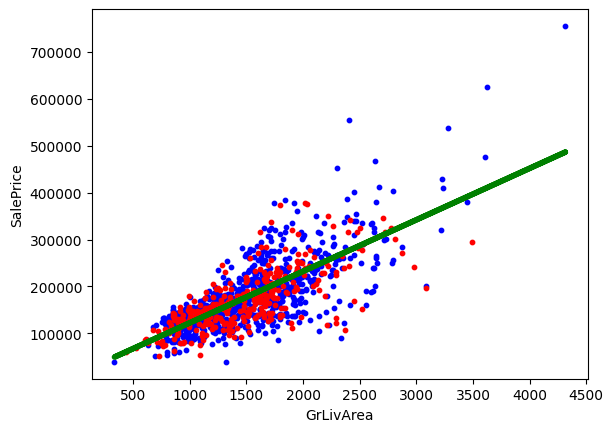

In [147]:
# Посмотрим на графике нашу траекторию
plt.plot(train['GrLivArea'], y_predict_train, linewidth=4, c='g')
plt.scatter(train['GrLivArea'], train['SalePrice'], s=10, c='b')
plt.scatter(test['GrLivArea'], test['SalePrice'], s=10, c='r')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

## добавление новой фичи на линейной регрессии

создадим фичу и применим маштабирование

 На графике видим что здесь подошла бы функция параболы больше

 пробуем  преобразовать в параболу для этого создаем еще одну фичу x**2 и умножаем на значение чтоб ее сжать к оси Y


In [148]:
df_new['GrLivArea2'] = df_new['GrLivArea'].apply(lambda x: ((x**2)*(x**2))) # создаем доп фичу подбирая под график

In [149]:
df_new['GrLivArea2'] = df_new['GrLivArea'].apply(lambda x: ((x**2))) # создаем доп фичу подбирая под график

In [150]:
# Преобразуем boolean столбцы в числовые (0 и 1) так как VIF не работает с bool
boolean_cols = df_new.select_dtypes(include='bool').columns
df_new[boolean_cols] = df_new[boolean_cols].astype(int)

In [151]:
df_new

,SalePrice,GrLivArea,GarageArea,OverallQual,Street_Grvl,Street_Pave,SaleCondition_Normal,GrLivArea2
0,208500,1710,548,7,0,1,1,2924100
1,181500,1262,460,6,0,1,1,1592644
2,223500,1786,608,7,0,1,1,3189796
4,250000,2198,836,8,0,1,1,4831204
5,143000,1362,480,5,0,1,1,1855044
...,...,...,...,...,...,...,...,...
1455,175000,1647,460,6,0,1,1,2712609
1456,210000,2073,500,6,0,1,1,4297329
1457,266500,2340,252,7,0,1,1,5475600
1458,142125,1078,240,5,0,1,1,1162084


In [152]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

In [153]:
# Создадим экземпляр StandardScaler
scaler = StandardScaler()

# Обучим StandardScaler на данных и преобразуем их
df_scaled = scaler.fit_transform(df_new)

# Преобразуем в DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df_new.columns)

print("\nМасштабированный DataFrame (StandardScaler):")
print(df_scaled)



Масштабированный DataFrame (StandardScaler):
      SalePrice  GrLivArea  GarageArea  OverallQual  Street_Grvl  Street_Pave  \
0      0.477371   0.436474    0.441887     0.754357    -0.064766     0.064766   
1      0.090052  -0.465520    0.000591    -0.004437    -0.064766     0.064766   
2      0.692547   0.589491    0.742771     0.754357    -0.064766     0.064766   
3      1.072693   1.419004    1.886131     1.513151    -0.064766     0.064766   
4     -0.462235  -0.264182    0.100885    -0.763232    -0.064766     0.064766   
...         ...        ...         ...          ...          ...          ...   
1192  -0.003191   0.309632    0.000591    -0.004437    -0.064766     0.064766   
1193   0.498888   1.167331    0.201180    -0.004437    -0.064766     0.064766   
1194   1.309387   1.704903   -1.042474     0.754357    -0.064766     0.064766   
1195  -0.474787  -0.835981   -1.102651    -0.763232    -0.064766     0.064766   
1196  -0.397682  -0.477600   -0.922120    -0.763232    -0.06476

снова строим модель на новой фиче

In [154]:
train, test = train_test_split(df_new, train_size=0.7, random_state=123)

In [155]:
X =train[['GrLivArea', 'GrLivArea2']]
y =train[['SalePrice']]

In [156]:
X_test =test[['GrLivArea', 'GrLivArea2']]
y_test =test[['SalePrice']]

In [157]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [158]:
# коэффициенты модели
print('w_0:', model.intercept_)
print('w_1, w_2:', model.coef_)

w_0: [65556.73421693]
w_1, w_2: [[4.35650396e+01 1.74613063e-02]]


In [159]:
y_predict_train = model.predict(X)
y_predict_test = model.predict(X_test)

In [160]:
# получаем MSE
from sklearn.metrics import mean_squared_error
train_mse = mean_squared_error(y, y_predict_train)
test_mse = mean_squared_error(y_test, y_predict_test)
print("Train MSE: {}".format(train_mse))
print("Test MSE: {}".format(test_mse))

Train MSE: 2063814611.9795291
Test MSE: 2292442179.2351995


In [161]:
# получаем MАE
from sklearn.metrics import mean_absolute_error
train_mae = mean_absolute_error(y, y_predict_train)
test_mae = mean_absolute_error(y_test, y_predict_test)
print("Train MAE: {}".format(train_mae))
print("Test MAE: {}".format(test_mae))

Train MAE: 31967.390509878885
Test MAE: 33759.69086845326


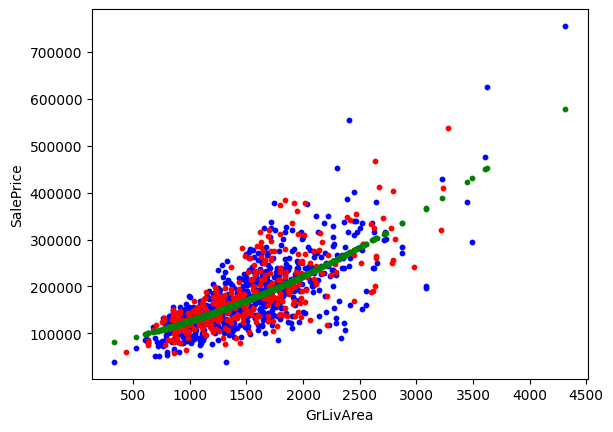

In [162]:
plt.scatter(train['GrLivArea'], train['SalePrice'], s=10, c='b')
plt.scatter(test['GrLivArea'], test['SalePrice'], s=10, c='r')
plt.scatter(train['GrLivArea'], y_predict_train, s=10, c='g')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

Вывод
 Не смотря на коррекцию  МSE и MAE отстались довольно таки высокими поэтому нужно будет подбирать другую модель

И хоть мы и сделали корректировку приближенно к очертанию  графика на показаниях MSE и MAE  это не сказалось в лучшую сторону

MAE: “Улучшенная” модель имеет меньший MAE на обучающем наборе, но больший MAE на тестовом наборе по сравнению с базовой моделью.

Это говорит о том, что “улучшения”, возможно, привели к небольшому переобучению.

MSE: Аналогично, “улучшенная” модель имеет меньший MSE на обучающем наборе, но больший MSE на тестовом наборе.

In [163]:
df_new

,SalePrice,GrLivArea,GarageArea,OverallQual,Street_Grvl,Street_Pave,SaleCondition_Normal,GrLivArea2
0,208500,1710,548,7,0,1,1,2924100
1,181500,1262,460,6,0,1,1,1592644
2,223500,1786,608,7,0,1,1,3189796
4,250000,2198,836,8,0,1,1,4831204
5,143000,1362,480,5,0,1,1,1855044
...,...,...,...,...,...,...,...,...
1455,175000,1647,460,6,0,1,1,2712609
1456,210000,2073,500,6,0,1,1,4297329
1457,266500,2340,252,7,0,1,1,5475600
1458,142125,1078,240,5,0,1,1,1162084


# Анализ

In [164]:
 #Анализ корреляции с целевой переменной (цена_лог)
correlation_with_target = correlation_matrix['SalePrice'].sort_values(ascending=False)

print("\nКорреляция с целевой переменной (цена):\n", correlation_with_target)


Корреляция с целевой переменной (цена):
 SalePrice                1.000000
OverallQual              0.791303
GrLivArea                0.708591
GarageArea               0.623470
SaleCondition_Partial    0.352009
Street_Pave              0.041054
SaleCondition_Alloca    -0.015550
Street_Grvl             -0.041054
SaleCondition_Family    -0.046513
SaleCondition_AdjLand   -0.050702
SaleCondition_Abnorml   -0.118148
SaleCondition_Normal    -0.153888
Name: SalePrice, dtype: float64


**Интерпретация матрицы корреляции и корреляции с целевой переменной**

Высокая положительная корреляция между "площадь" и "цена" (например, 0.79) означает, что с увеличением площади  цены также увеличивается.
Высокая отрицательная корреляция (например, -0.15) означает обратную зависимость .
Корреляция близкая к 0 означает слабую или отсутствующую линейную зависимость.

In [165]:
#  Анализ на мультиколлинеарность (VIF - Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [166]:
#Удалим GrLivArea2 из-за мультиколлинеарности
df_new = df_new.drop('GrLivArea2', axis=1)


# Вычисляем VIF для каждого признака (кроме целевой переменной)
X = df_new.drop('SalePrice', axis=1)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

print("\nVariance Inflation Factor (VIF):\n", vif_data)


Variance Inflation Factor (VIF):
                 feature       VIF
0             GrLivArea  1.572765
1            GarageArea  1.437717
2           OverallQual  1.719471
3           Street_Grvl       inf
4           Street_Pave       inf
5  SaleCondition_Normal  0.000000


/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


**Интерпретация VIF**
 * VIF = 1: Нет мультиколлинеарности.
 * 1 < VIF < 5: Умеренная мультиколлинеарность.  Возможно, стоит обратить внимание.
 * VIF >= 5: Высокая мультиколлинеарность.  Стоит рассмотреть удаление одного из сильно коррелирующих признаков.
 * VIF >= 10: Очень высокая мультиколлинеарность.  Проблема, требующая немедленного решения.

**Анализ линейной регрессии с доп.фичей:**
база

* Train MAE: 34051.43676672327
* Test MAE: 30999.57628182205

* Train MSE: 2299115712.017429
* Test MSE: 1886093864.380271

улучшенная
* Train MAE: 31967.390509878885
* Test MAE: 33759.69086845326

* Train MSE: 2063814611.9795291
* Test MSE: 2292442179.2351995

Сопоставимые значения на train и test:

**Значения MAE и MSE** на обучающем и тестовом наборах относительно близки друг к другу. Это указывает на то, что модель линейной регрессии, вероятно, не переобучается и достаточно хорошо обобщает данные.


**Величины ошибок:** MAE около 32000-34000 и MSE около 2 миллиардов - это достаточно большие значения. Это означает, что модель в среднем ошибается на 32-34 тысячи в абсолютном выражении, а среднеквадратичная ошибка еще больше. Зависят от масштаба целевой переменной.

**Вывод по линейной регрессии:**

Базовая модель линейной регрессии является предпочтительнее, т.к. дает меньше ошибки на тестовом наборе. Улучшения, которые были внесены в модель, скорее всего, увеличили переобучение и снизили обобщающую способность.

**Наблюдается**
* 1 < VIF < 5: Умеренная мультиколлинеарность


* наблюдается гетероскедостичность- не совсем подходит линейной модели

**Общий Вывод**


 стоит  посмотреть другую модель

# Обучение  моделью дерево база

In [167]:
from sklearn.tree import DecisionTreeRegressor

In [168]:
X =df_new[['GrLivArea']]
y =df_new[['SalePrice']]

In [169]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [170]:
# 5.1. Без новых признаков (базовая модель)
model_dt_base = DecisionTreeRegressor(random_state=42)
model_dt_base.fit(X_train, y_train)

y_pred_dt_base_tr = model_dt_base.predict(X_train)
y_pred_dt_base_tx = model_dt_base.predict(X_test)

In [171]:
train_mse = mean_squared_error(y_train, y_pred_dt_base_tr)
test_mse = mean_squared_error(y_test, y_pred_dt_base_tx)
print("Train MSE: {}".format(train_mse))
print("Test MSE: {}".format(test_mse))

Train MSE: 456940679.6340822
Test MSE: 3415071148.2508497


In [172]:
train_mae = mean_absolute_error(y_train, y_pred_dt_base_tr)
test_mae = mean_absolute_error(y_test, y_pred_dt_base_tx)
print("Train MAE: {}".format(train_mae))
print("Test MAE: {}".format(test_mae))

Train MAE: 11117.115541208846
Test MAE: 41457.89025488401


**Анализ для дерева:**

**Переобучение:**

Разница между значениями MAE и MSE на обучающем и тестовом наборах очень велика. На обучающем наборе ошибки значительно меньше, чем на тестовом. Это явный признак переобучения. Модель выучила обучающие данные “назубок” и плохо обобщает на новые, незнакомые данные.

**Значительные ошибки на тестовом наборе:** MAE около 41000 и MSE около 3.4 миллиардов на тестовом наборе указывают на то, что модель дерева решений плохо прогнозирует значения для новых данных.

**Вывод**

**Рекомендации:**


**Feature Engineering:** Попробуем подумать о создании новых признаков, которые могут улучшить производительность моделей.

**Удалить выбросы:**Необходимо обнаружить и удалить выбросы из данных, чтобы улучшить производительность моделей


**Линейная регрессия:** Примените регуляризацию (L1 или L2) к линейной регрессии, чтобы предотвратить переобучение. Попробуйте Ridge или Lasso регрессию.

**Дерево решений:**Ограничьте глубину дерева, установите минимальное количество образцов для разделения узла или используйте обрезку дерева.

**Масштабирование признаков:** Масштабирование признаков - важный шаг в предварительной обработке данных. Масштабирование признаков не влияет на результат моделей на основе деревьев, но сильно влияет на результат линейной регрессии.

**Кросс-валидация:** Используйте кросс-валидацию для более точной оценки производительности моделей и выбора лучших параметров.

# делаем преобразование:
- удаляем выбросы
- используем все столбцы
- используем кросс-валидацию
- ограничиваем глубину дерева
- делаем обрезку дерева


In [181]:
df_new

,SalePrice,GrLivArea,GarageArea,OverallQual,Street_Grvl,Street_Pave,SaleCondition_Normal
0,208500.0,1710,548,7,0,1,1
1,181500.0,1262,460,6,0,1,1
2,223500.0,1786,608,7,0,1,1
4,250000.0,2198,836,8,0,1,1
5,143000.0,1362,480,5,0,1,1
...,...,...,...,...,...,...,...
1455,175000.0,1647,460,6,0,1,1
1456,210000.0,2073,500,6,0,1,1
1457,266500.0,2340,252,7,0,1,1
1458,142125.0,1078,240,5,0,1,1


In [182]:
# функция удаления выбросов
def remove_outliers_iqr(df, column_name):
    """Удаляет выбросы из указанного столбца, заменяя их значениями 'усов'."""

    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Заменяем значения меньше нижней границы на нижнюю границу
    df[column_name] = np.where(df[column_name] < lower_bound, lower_bound, df[column_name])

    # Заменяем значения больше верхней границы на верхнюю границу
    df[column_name] = np.where(df[column_name] > upper_bound, upper_bound, df[column_name])

    return df

# Применяем функцию к столбцу 'SalePrice'
df_new = remove_outliers_iqr(df_new, 'SalePrice')

print(df_new['SalePrice'].describe()) #Проверяем что максимум и минимум находятся между lower_bound и upper_bound


count      1197.000000
mean     172604.899749
std       60449.813293
min       39300.000000
25%      130000.000000
50%      160000.000000
75%      205000.000000
max      317500.000000
Name: SalePrice, dtype: float64


In [183]:
X = df_new.drop('SalePrice', axis=1) # Исключаем исходную цену, но используем цену_лог как целевую
y = df_new['SalePrice']

In [184]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [185]:
model_dt = DecisionTreeRegressor(max_depth=5, random_state=42) # Ограничение глубины дерева
model_dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [186]:
from sklearn.model_selection import cross_val_score # для кросc-валидации

In [187]:
# 1. Оценка MAE на кросс-валидации
cv_scores_mae_dt = cross_val_score(model_dt, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_mae_dt = -cv_scores_mae_dt  # Инвертируем знак, так как scoring возвращает отрицательные значения
print(f"Дерево решений (ограниченная глубина) CV MAE: {cv_mae_dt.mean():.2f} (+/- {cv_mae_dt.std():.2f})")

# 2. Оценка MSE на кросс-валидации
cv_scores_mse_dt = cross_val_score(model_dt, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_mse_dt = -cv_scores_mse_dt  # Инвертируем знак, так как scoring возвращает отрицательные значения
print(f"Дерево решений (ограниченная глубина) CV MSE: {cv_mse_dt.mean():.2f} (+/- {cv_mse_dt.std():.2f})")

Дерево решений (ограниченная глубина) CV MAE: 22239.28 (+/- 698.64)
Дерево решений (ограниченная глубина) CV MSE: 897676221.48 (+/- 56504645.48)


In [190]:
# 3. Предсказание и оценка на тестовой выборке (для сравнения)
y_pred_dt_tr = model_dt.predict(X_train)
y_pred_dt_ts = model_dt.predict(X_test)

# 1. Вычисляем MAE
mae_dt_test = mean_absolute_error(y_train, y_pred_dt_tr)
print(f"Дерево решений (train) MAE: {mae_dt_test:.2f}")
mae_dt_test = mean_absolute_error(y_test, y_pred_dt_ts)
print(f"Дерево решений (test) MAE: {mae_dt_test:.2f}")
print()
# 2. Вычисляем MSE
mse_dt_test = mean_squared_error(y_train,y_pred_dt_tr)
print(f"Дерево решений (train) MSE: {mse_dt_test:.2f}")
mse_dt_test = mean_squared_error(y_test, y_pred_dt_ts)
print(f"Дерево решений (Test) MSE: {mse_dt_test:.2f}")

Дерево решений (train) MAE: 18266.64
Дерево решений (test) MAE: 22423.89

Дерево решений (train) MSE: 619627044.92
Дерево решений (Test) MSE: 867717858.15


**Сравнение базового и улучшенного дерева решений:**

* Train MAE: 11117.115541208846
* Test MAE: 41457.89025488401

* Train MSE: 456940679.6340822
* Test MSE: 3415071148.2508497

улучшенная
 * (train) MAE: 18266.64
 * (test) MAE: 22423.89

 * (train) MSE: 619627044.92
 * (Test) MSE: 867717858.15


MAE: “Улучшенная” модель имеет больший MAE на обучающем наборе, но значительно меньший MAE на тестовом наборе.

MSE: “Улучшенная” модель имеет больший MSE на обучающем наборе, но значительно меньший MSE на тестовом наборе.

**Вывод по дереву решений:**

“Улучшенная” модель дерева решений намного лучше базовой модели. Значительное снижение ошибок на тестовом наборе указывает на то, что улучшения эффективно уменьшили переобучение и повысили способность модели к обобщению.

**Общие выводы и рекомендации:**

Базовая линейная регрессия лучше улучшенной: улучшения для линейной регрессии привели к незначительному переобучению. Базовая модель предпочтительнее.

Улучшенное дерево решений значительно лучше базового: Улучшения для дерева решений были очень успешными и значительно улучшили способность модели к обобщению.

Рекомендация рассмотреть возможность использования других моделей машинного обучения, которые могут лучше подходить для ваших данных, например, Random Forest или Gradient Boosting.